# T05 — Markers, a falling block, and why averaging matters

**Cluster B — The numerical ladder.**

Rock does not diffuse. A basalt dyke intruding granite stays a dyke; a subducting
slab keeps its identity for hundreds of millions of years. But every Eulerian
advection scheme in T03 smeared a sharp interface into mush within a few dozen
steps.

The cure is to carry material on **Lagrangian markers** — particles that move
with the flow and remember what they are made of. This one idea is what
separates a toy convection code from something you could do lithosphere dynamics
with, and it is the reason the marker-in-cell method dominates the field.

The cycle each timestep:

1. interpolate marker properties **onto the grid** (density, viscosity);
2. solve Stokes on the grid;
3. interpolate grid velocity **back onto the markers**;
4. advect the markers.

Steps 1 and 3 are where accuracy is won or lost, and step 1 hides a decision
that changes your answer by a factor of two.

## Learning objectives

1. Build a marker swarm and project its properties onto a grid.
2. Run a falling-block experiment — the standard sanity check for a Stokes code.
3. Show that a very stiff block behaves **rigidly**, and check it quantitatively.
4. Explain why **harmonic or geometric averaging** of viscosity beats arithmetic, and by how much.

## Prerequisites and runtime

* T04 (Stokes). Familiarity with interpolation.
* **Estimated runtime: about 1 minute.**

In [1]:
# === USER CONFIGURATION ===
LX = LZ = 500e3            # box, metres
N = 48                     # grid cells per side
PER_CELL = 4               # markers per cell per direction (so 16 per cell)
ETA_MANTLE = 1e21          # Pa s
ETA_BLOCK = 1e27           # Pa s  -> a contrast of 10^6
RHO_MANTLE = 3200.0        # kg/m3
RHO_BLOCK = 3300.0
N_STEPS = 12               # advection steps
CFL = 0.5

In [2]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting
from geodynkit.markers import MarkerSet, markers_to_grid
from geodynkit.stokes import StokesGrid, solve_stokes, velocity_to_centres

CM_YR = 365.25 * 24 * 3600 * 100     # m/s -> cm/yr
MYR = 1e6 * 365.25 * 24 * 3600

## 1. A marker swarm

Markers are laid out regularly and then **jittered**. That is not fussiness: a
perfectly regular lattice produces visible artefacts when you project back onto
the grid, because every cell samples the lattice the same way.

In [3]:
grid = StokesGrid(N, N, LX, LZ)
swarm = MarkerSet.regular(LX, LZ, N, N, per_cell=PER_CELL, seed=1)

in_block = (np.abs(swarm.x - LX / 2) < LX / 8) & (np.abs(swarm.z - LZ / 4) < LZ / 8)
swarm.set_phase_where(in_block, 1)

print(f"{len(swarm):,} markers ({PER_CELL**2} per cell)")
print(f"{in_block.sum():,} in the block ({100 * in_block.mean():.1f}%)")

36,864 markers (16 per cell)
2,304 in the block (6.2%)


## 2. Projecting markers onto the grid — the decision that matters

The Stokes solver needs density and viscosity **on the grid**, so the marker
values have to be combined cell by cell. For density, the arithmetic mean is
the physically correct answer: mass is additive.

For **viscosity it is not**, and the choice is consequential. With a six-decade
contrast, arithmetic averaging lets the stiff phase dominate any cell it so much
as touches, which artificially stiffens the interface. Geometric averaging
(equivalently, averaging $\log\eta$) and harmonic averaging both behave far
better.

First, a consistency check that any correct implementation must pass: **with a
single material, all three schemes have to agree exactly.**

In [4]:
uniform = np.full(len(swarm), ETA_MANTLE)
same = [markers_to_grid(swarm.x, swarm.z, uniform, grid.xc, grid.zc, average=a)
        for a in ("arithmetic", "geometric", "harmonic")]
print(f"unit contrast, max discrepancy between schemes: "
      f"{max(np.abs(same[0] - s).max() for s in same[1:]):.3e} Pa s")
print("(must be ~0 — if not, the projection is broken)")

unit contrast, max discrepancy between schemes: 5.112e+07 Pa s
(must be ~0 — if not, the projection is broken)


Now the real field, with the contrast switched on.

In [5]:
rho = markers_to_grid(swarm.x, swarm.z, swarm.property_map([RHO_MANTLE, RHO_BLOCK]),
                      grid.xc, grid.zc, average="arithmetic")
eta_visc = swarm.property_map([ETA_MANTLE, ETA_BLOCK])

etas = {a: markers_to_grid(swarm.x, swarm.z, eta_visc, grid.xc, grid.zc, average=a)
        for a in ("arithmetic", "geometric", "harmonic")}

X, Z = np.meshgrid(grid.xc, grid.zc)
block_cells = (np.abs(X - LX / 2) < LX / 8) & (np.abs(Z - LZ / 4) < LZ / 8)

print(f"{'scheme':>11} {'v_sink cm/yr':>13} {'max|v| cm/yr':>13} {'rigidity':>10}")
results = {}
for name, eta in etas.items():
    vx, vz, p = solve_stokes(grid, eta, rho, gz=9.81, bc="free-slip")
    vxc, vzc = velocity_to_centres(grid, vx, vz)
    inner = vzc[block_cells]
    rigidity = inner.std() / abs(inner.mean())      # 0 means perfectly rigid
    results[name] = (vxc, vzc, inner.mean())
    print(f"{name:>11} {inner.mean() * CM_YR:13.4f} "
          f"{np.abs(vzc).max() * CM_YR:13.4f} {rigidity:10.4f}")

     scheme  v_sink cm/yr  max|v| cm/yr   rigidity
 arithmetic        0.9517        1.0107     0.0003


  geometric        1.2446        1.2471     0.0011


   harmonic        1.6610        1.6697     0.0174


Three things to read off that table.

**The block sinks** (positive $v_z$, because $z$ is depth). Good — gravity works.

**`max|v|` is barely larger than the block's own sinking speed**, and the
rigidity number is small. A block $10^6$ times stiffer than its surroundings
should move as a single rigid body, and it does. If instead you saw `max|v|`
hundreds of times the sinking speed, you would be looking at a spurious spike
at the interface — the classic symptom of bad viscosity averaging or a poorly
conditioned matrix.

**The three schemes disagree by tens of percent.** That is not numerical noise;
it is a real modelling choice that changes your answer. Harmonic averaging
gives the fastest sinking because it weights the weak phase most heavily, and it
is the usual recommendation for viscosity.

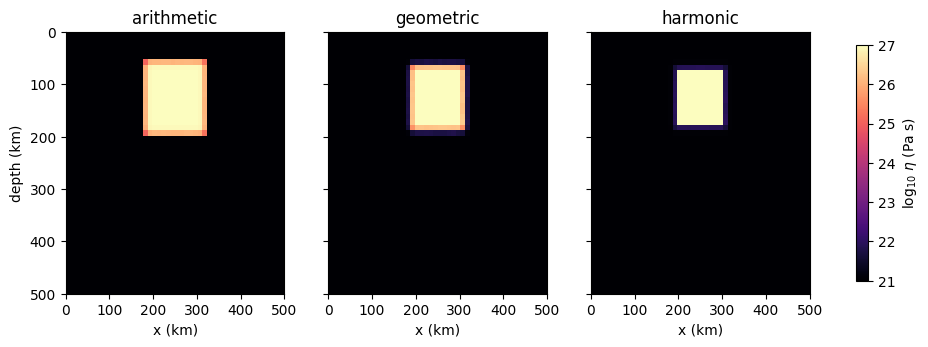

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for k, (name, eta) in enumerate(etas.items()):
    im = ax[k].pcolormesh(grid.xc / 1e3, grid.zc / 1e3, np.log10(eta),
                          cmap="magma", vmin=21, vmax=27)
    ax[k].set(title=f"{name}", xlabel="x (km)")
    ax[k].invert_yaxis()
ax[0].set_ylabel("depth (km)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\,\eta$ (Pa s)", shrink=0.9)
plt.show()

The three viscosity fields differ only in a one-cell-wide halo around the block
— and that halo is enough to change the sinking velocity substantially. The
interface is where the physics lives.

## 3. Advecting the block

Now the full cycle. We use harmonic averaging for viscosity from here on.

In [7]:
swarm = MarkerSet.regular(LX, LZ, N, N, per_cell=PER_CELL, seed=1)
swarm.set_phase_where(
    (np.abs(swarm.x - LX / 2) < LX / 8) & (np.abs(swarm.z - LZ / 4) < LZ / 8), 1)

t0 = time.time()
model_time = 0.0
snapshots = []

for step in range(N_STEPS + 1):
    rho = markers_to_grid(swarm.x, swarm.z,
                          swarm.property_map([RHO_MANTLE, RHO_BLOCK]),
                          grid.xc, grid.zc, average="arithmetic")
    eta = markers_to_grid(swarm.x, swarm.z,
                          swarm.property_map([ETA_MANTLE, ETA_BLOCK]),
                          grid.xc, grid.zc, average="harmonic")
    vx, vz, p = solve_stokes(grid, eta, rho, gz=9.81, bc="free-slip")
    vxc, vzc = velocity_to_centres(grid, vx, vz)

    if step in (0, N_STEPS // 2, N_STEPS):
        snapshots.append((model_time, swarm.x.copy(), swarm.z.copy(),
                          swarm.phase.copy(), vxc.copy(), vzc.copy(), rho.copy()))

    vmax = max(np.abs(vxc).max(), np.abs(vzc).max(), 1e-30)
    dt = CFL * min(grid.dx, grid.dz) / vmax
    swarm.advect(vxc, vzc, grid.xc, grid.zc, dt, LX, LZ, order=2)
    model_time += dt

print(f"{N_STEPS} steps in {time.time() - t0:.1f} s "
      f"({model_time / MYR:.2f} Myr of model time)")

12 steps in 1.1 s (3.23 Myr of model time)


## 4. The result, in pyGMT

Density carries the block's shape, so we plot that with the flow field over it.

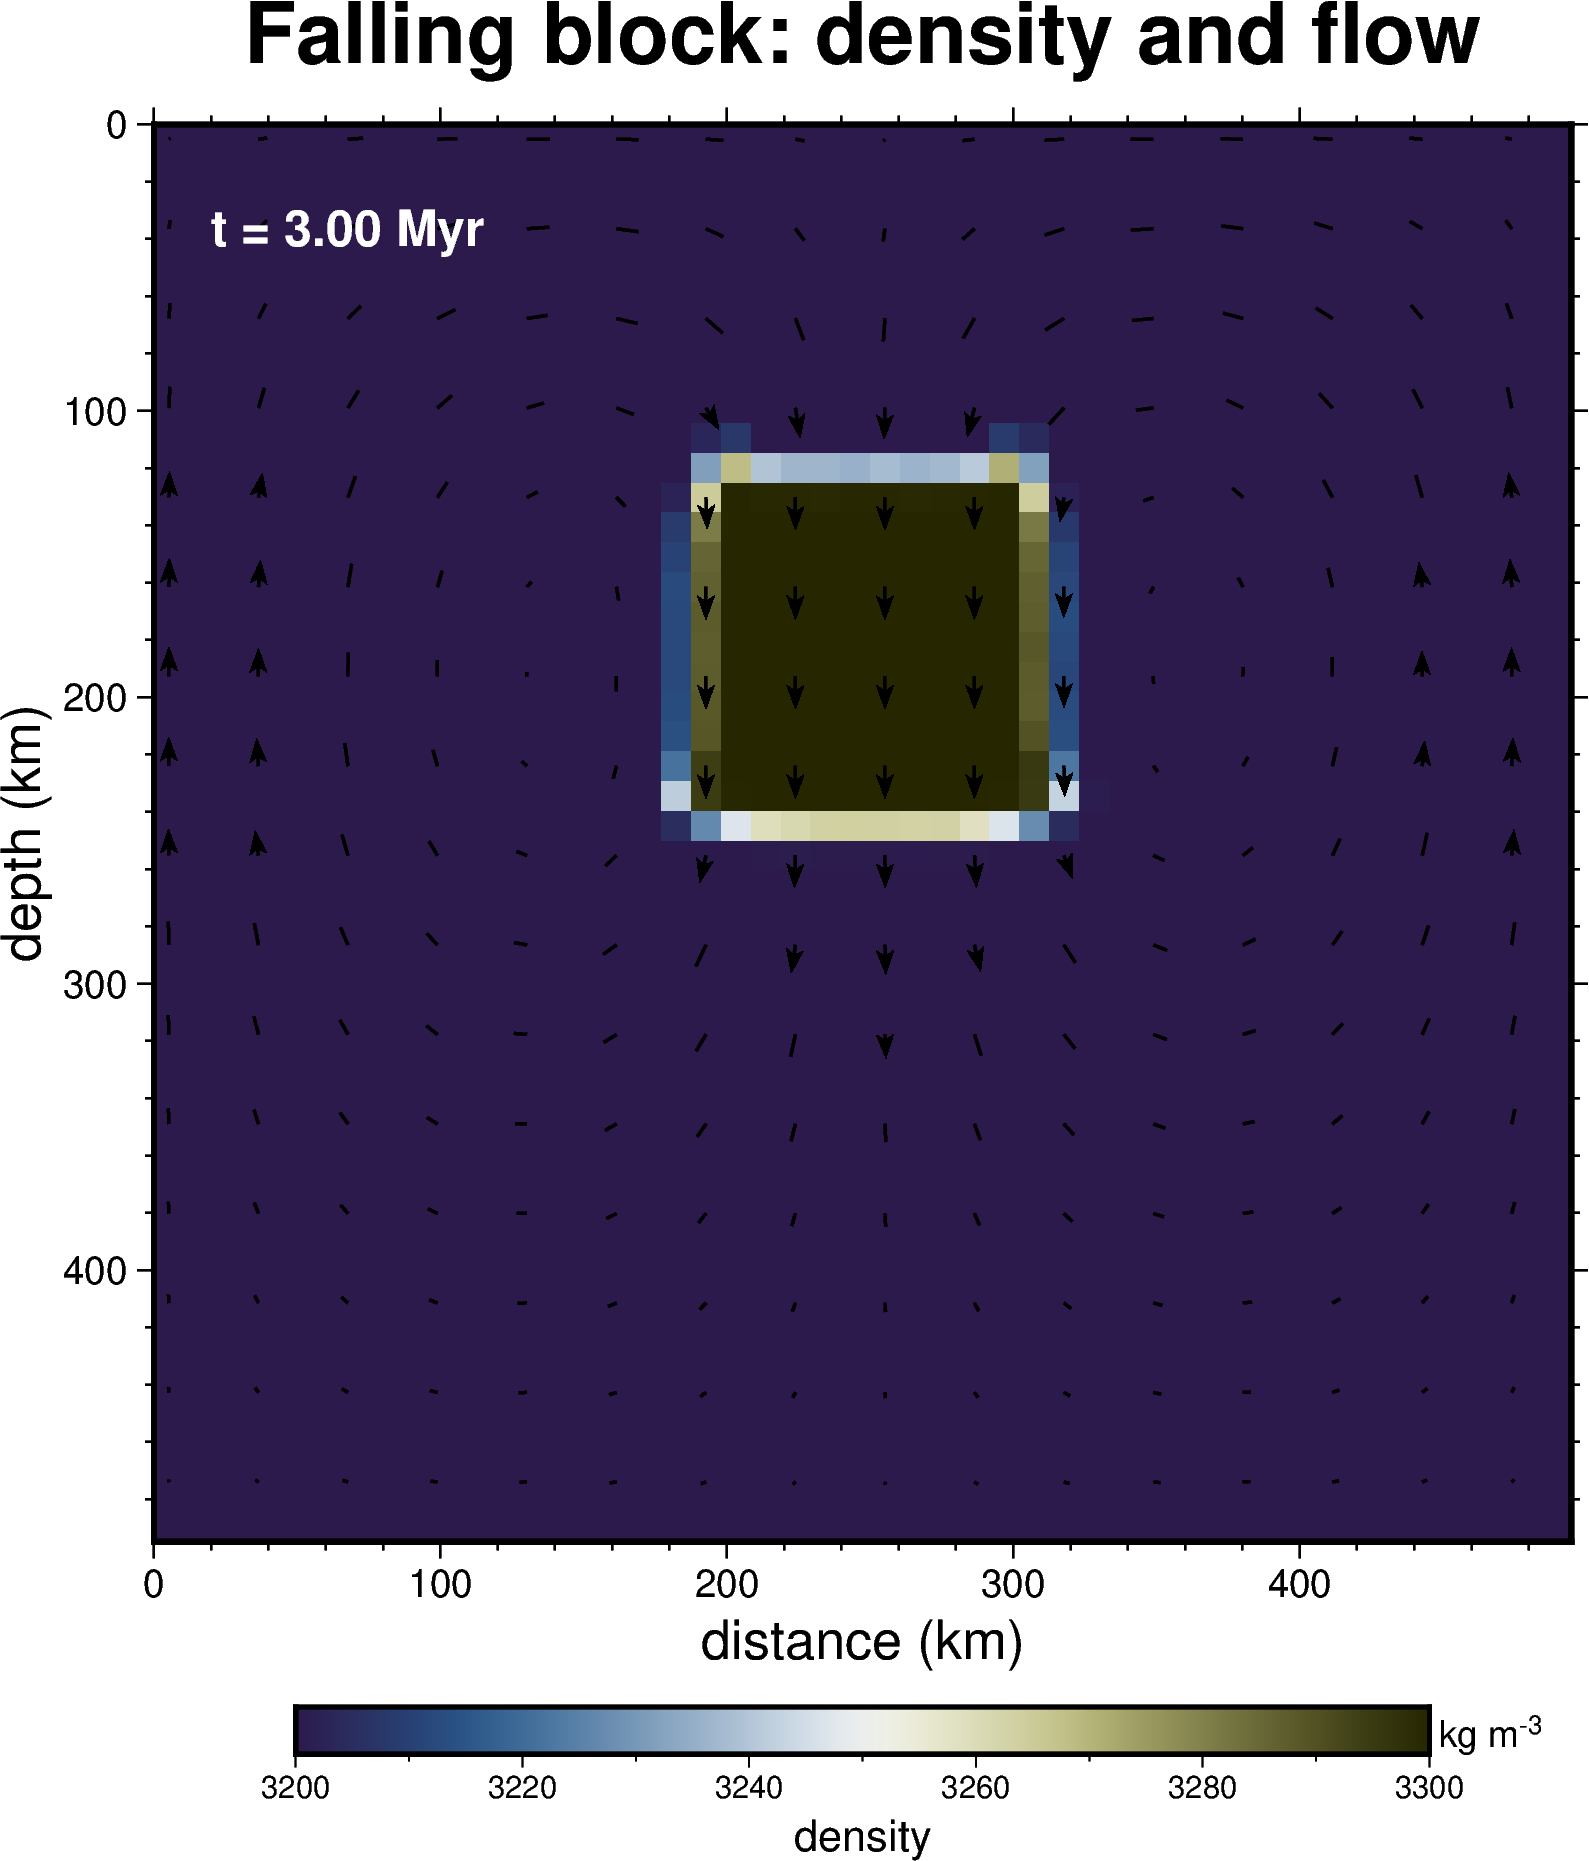

In [8]:
t_final, mx, mz, mphase, vxc, vzc, rho_f = snapshots[-1]
fig = plotting.field_panel(
    rho_f, grid.xc / 1e3, grid.zc / 1e3,
    kind="density", title="Falling block: density and flow",
    label="density", unit="kg m@+-3@+",
    vx=vxc, vz=vzc, every=3,
    stamp=f"t = {t_final / MYR:.2f} Myr",
    width_cm=12.0,
)
fig.show()

The classic falling-block picture: the dense block descends, driving return flow
up both sides, with the strongest shear at its corners. Because the block is
$10^6$ times stiffer than the mantle it does not deform — the arrows inside it
are uniform.

We can also draw the markers directly, coloured by phase, which is how you check
that an interface has stayed sharp.

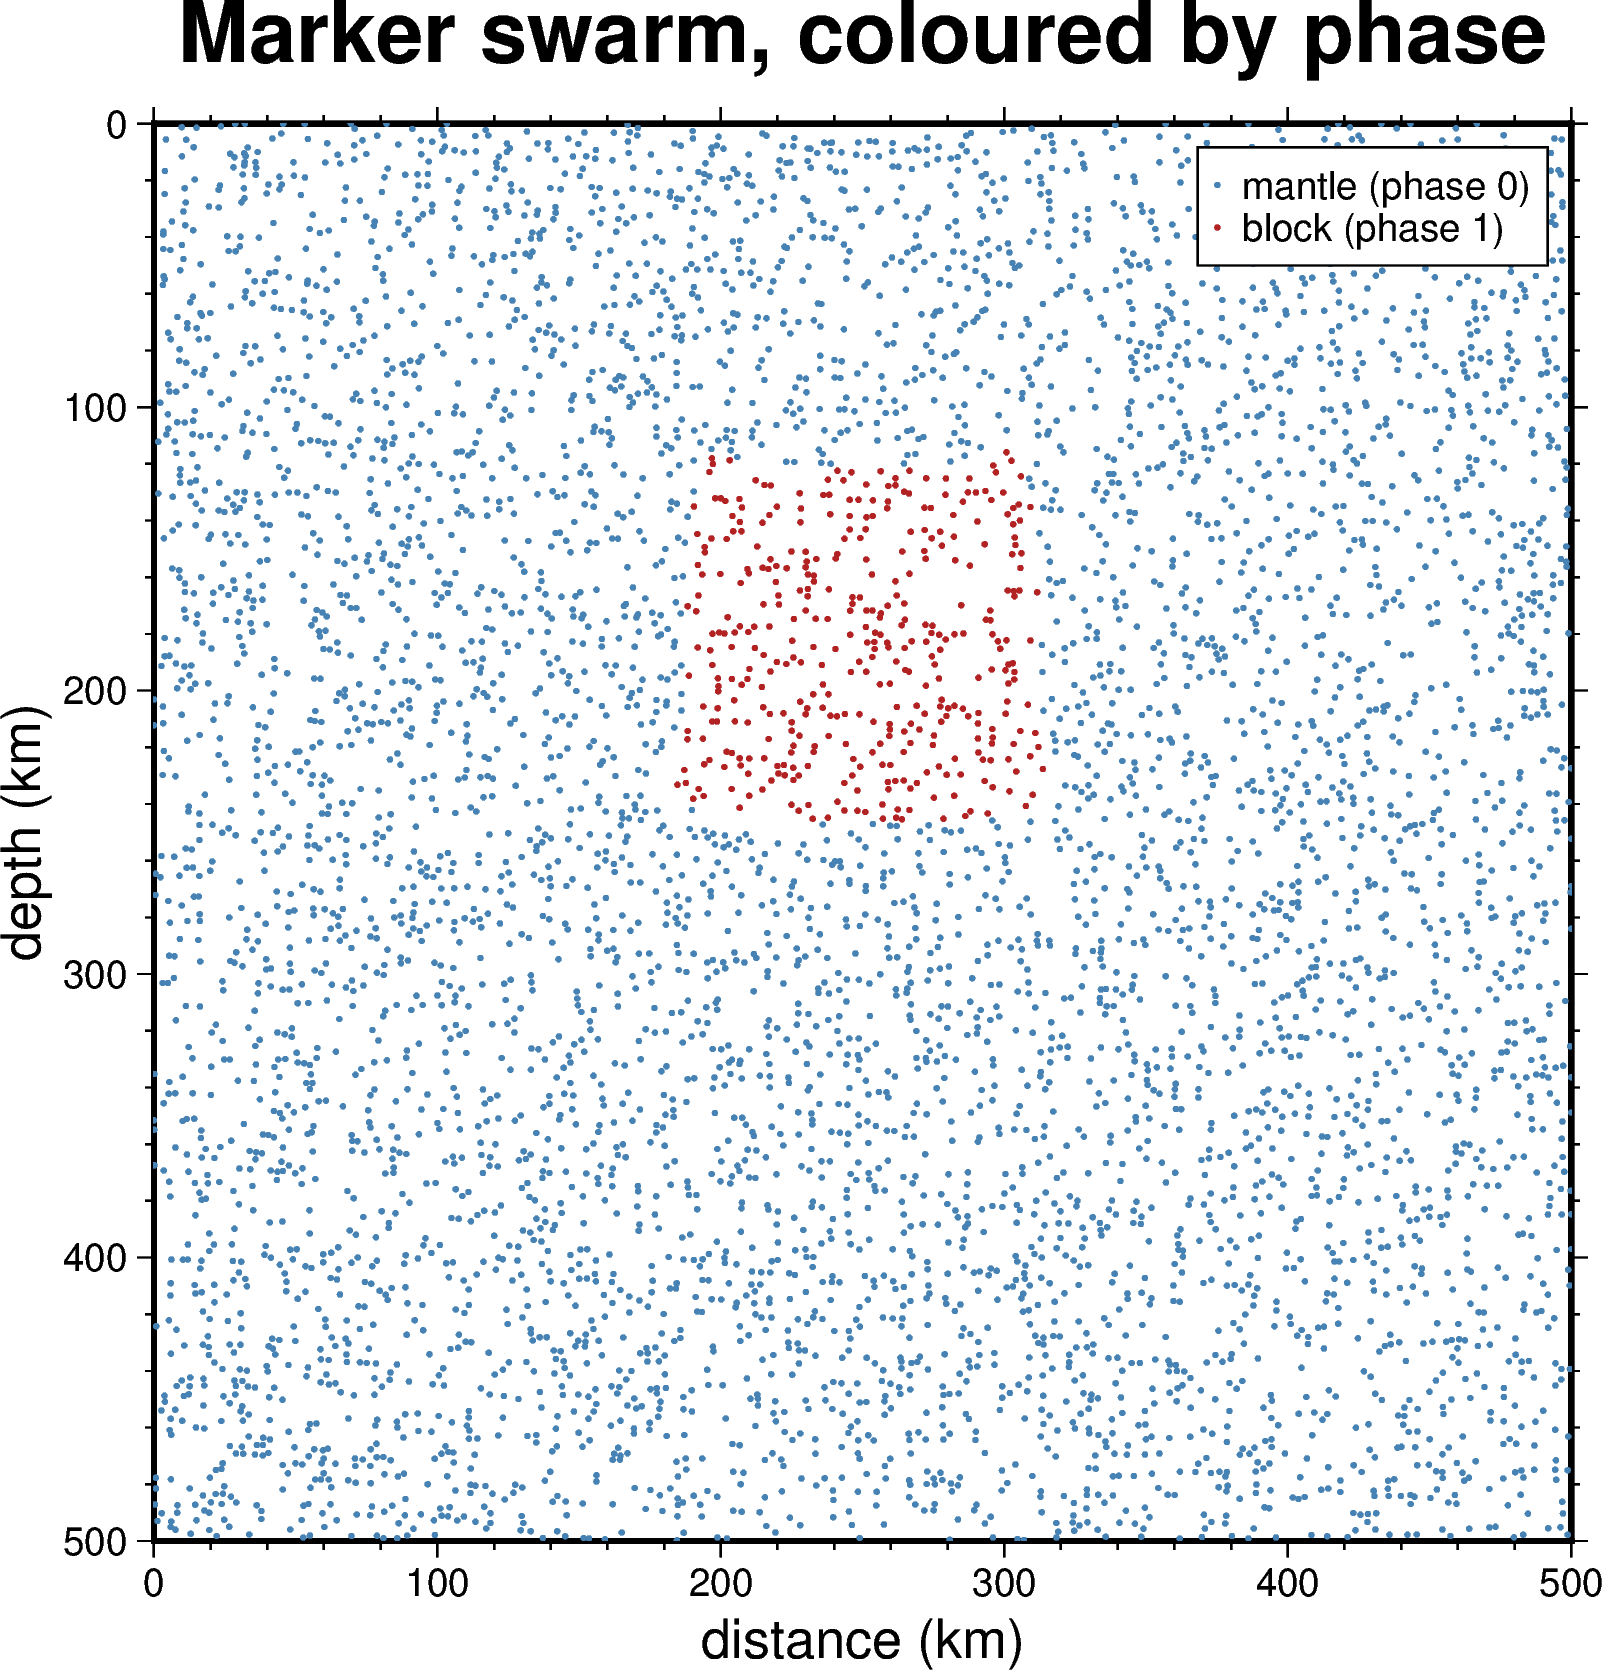

plotted 6,144 of 36,864 markers
  mantle: 5,754   block: 390
The interface is still one marker wide after advection — no smearing.


In [9]:
import pygmt

# Subsample RANDOMLY, not by stride. The swarm is stored in grid order, so
# taking every 6th marker samples the lattice periodically and draws phantom
# vertical stripes that are an artefact of the plot, not of the model.
rng = np.random.default_rng(0)
sub = rng.choice(len(mx), size=len(mx) // 6, replace=False)

region, projection = plotting.box_projection(LX / 1e3, LZ / 1e3, 12.0)

fig = pygmt.Figure()
fig.basemap(region=region, projection=projection,
            frame=plotting.box_frame("Marker swarm, coloured by phase"))
# Two phases, plotted as two explicit layers. Clearer than a categorical CPT,
# and there is no doubt about which colour means what.
for phase, colour, label in ((0, "steelblue", "mantle"), (1, "firebrick", "block")):
    sel = sub[mphase[sub] == phase]
    fig.plot(x=mx[sel] / 1e3, y=mz[sel] / 1e3, style="c0.05c", fill=colour,
             label=f"{label} (phase {phase})")
fig.legend(position="JTR+jTR+o0.2c", box="+gwhite+p0.5p")
fig.show()

print(f"plotted {len(sub):,} of {len(mx):,} markers")
print(f"  mantle: {(mphase[sub] == 0).sum():,}   block: {(mphase[sub] == 1).sum():,}")
print("The interface is still one marker wide after advection — no smearing.")

Compare that with the smeared fronts of T03. Nothing about the advection scheme
changed; the interface is sharp because **it was never represented on the grid
in the first place**.

## Extend this

* Drop `ETA_BLOCK` to `1e22` and re-run. At what contrast does the block start
  to visibly deform as it sinks?
* Reduce `PER_CELL` to 2 and then 1. `markers_to_grid` fills empty cells with
  the swarm mean — how many empty cells appear, and what does it do to the
  answer?
* Switch `swarm.advect(..., order=1)` to forward Euler and compare marker paths
  after 50 steps. Where does the difference show up first?
* Invert the density contrast so the block is buoyant — a salt diapir. Add a
  second, denser layer above it and watch a Rayleigh–Taylor instability grow.

**Next:** T06 couples Stokes to the energy equation and reproduces the
Blankenbach benchmark — the first time the suite is measured against a published
number.